Parsed 90 blocks successfully.
    Node  Block  ProductionTime_ms  StartDelay_ms
0  Alice   3032             3591.0           43.0
1  Alice   3037             3585.0           44.0
2  Alice   3042             3602.0           39.0
3  Alice   3047             3599.0           39.0
4  Alice   3052             3151.0           38.0


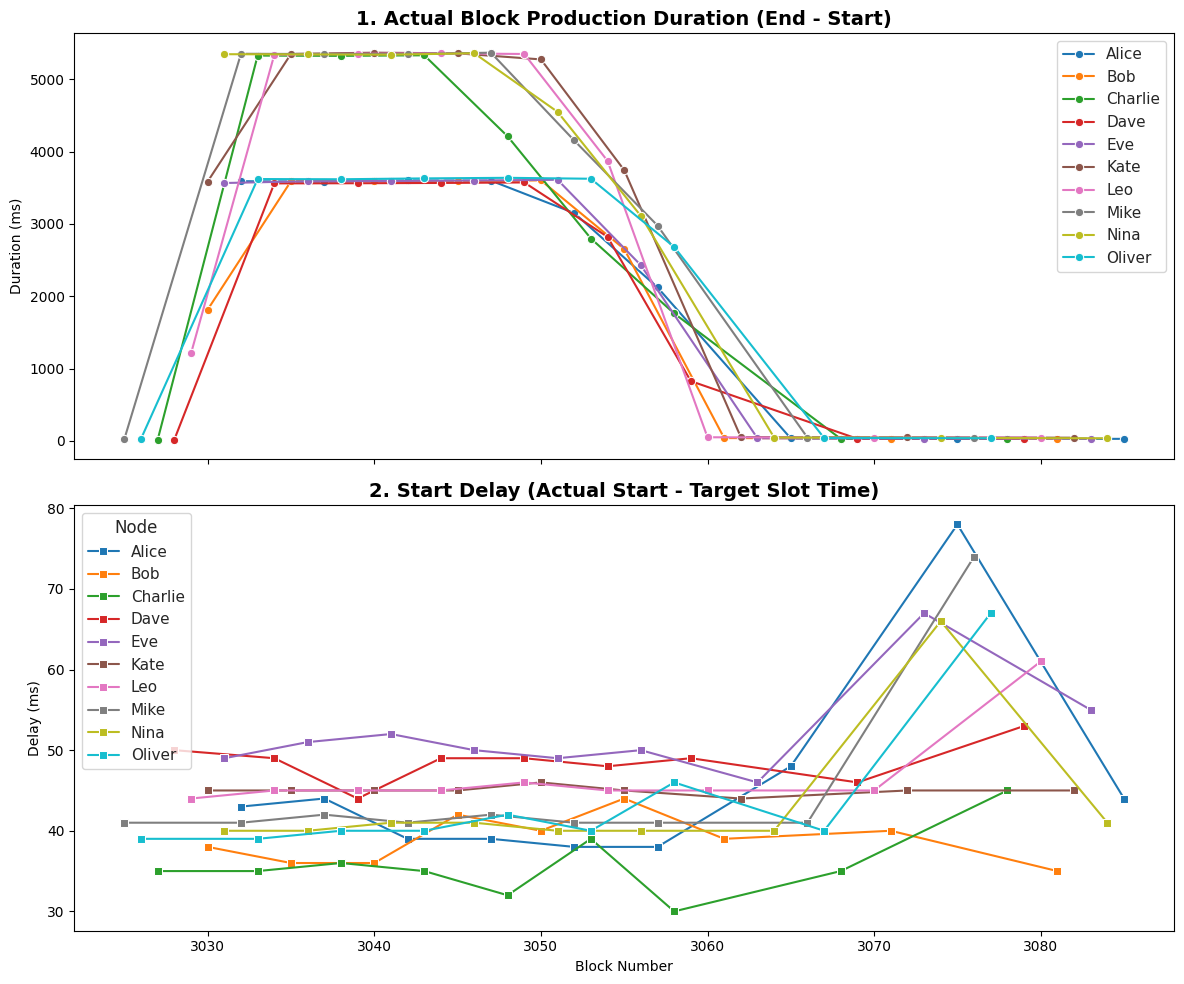

In [2]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import glob
import os

RELAYS = [
    "ferdie",
    "george",
    "henry",
    "iris",
    "jack",
    "paul",
    "quinn",
    "rita",
    "sam",
    "tom"
]

BLOCK_PRODUCERS = [
    "alice",
    "bob",
    "charlie",
    "dave",
    "eve",
    "kate",
    "leo",
    "mike",
    "nina",
    "oliver"
]


# ---------------------------------------------------------
# STEP 1: GET DATA
# ---------------------------------------------------------
empty_blocks = '/home/christos/IOHK/repos/partner-chains/e2e-tests/utils/logs/from_2026-01-15_17-35-00_to_2026-01-15_17-50-00/'
test_490_txs = '/home/christos/shielded/jupyter/2026-01-14/all_logs/'
new_200_txs = '/home/christos/IOHK/repos/partner-chains/e2e-tests/utils/logs/from_2026-01-15_21-38-08_to_2026-01-15_21-44-01/'

# Set active log directory here
logs_dir = test_490_txs

files_to_process = []
for node in BLOCK_PRODUCERS:
    # os.path.join automatically adds the '/' if logs_dir doesn't have it
    files_to_process.append(os.path.join(logs_dir, f"{node}.txt"))

# # ---------------------------------------------------------
# # STEP 2: PARSE THE LOGS
# # ---------------------------------------------------------

def parse_substrate_logs_robust(file_list):
    data = []
    
    # 1. Regex to capture Timestamp and the rest of the message
    # Matches: 2026-01-15 17:39:36.048  INFO ...
    base_pattern = re.compile(r"^(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}\.\d{3})\s+(.*)")
    
    # 2. Regex for START event (captures Parent Block #)
    # Matches: ... Starting consensus session on top of parent ... (#14406)
    start_pattern = re.compile(r"Starting consensus session on top of parent .* \(#(\d+)\)")
    
    # 3. Regex for END event (captures Current Block #)
    # Matches: ... Prepared block for proposing at 14407 ...
    end_pattern = re.compile(r"Prepared block for proposing at (\d+)")

    for filename in file_list:
        node_name = os.path.splitext(os.path.basename(filename))[0].capitalize()
        
        # Dictionary to store timestamps for each block
        # Structure: { 14407: {'start': datetime, 'end': datetime}, ... }
        block_events = {}
        
        with open(filename, 'r') as f:
            for line in f:
                line = line.strip()
                if not line: continue
                
                # Extract Timestamp
                base_match = base_pattern.search(line)
                if not base_match: continue
                
                timestamp_str = base_match.group(1)
                message = base_match.group(2)
                
                try:
                    current_time = datetime.strptime(timestamp_str, "%Y-%m-%d %H:%M:%S.%f")
                except ValueError:
                    continue

                # --- CHECK FOR START (Parent Block) ---
                start_match = start_pattern.search(message)
                if start_match:
                    parent_block = int(start_match.group(1))
                    # If we are working on top of 14406, we are building 14407
                    target_block = parent_block + 1
                    
                    if target_block not in block_events: block_events[target_block] = {}
                    block_events[target_block]['start'] = current_time
                    continue

                # --- CHECK FOR END (Current Block) ---
                end_match = end_pattern.search(message)
                if end_match:
                    target_block = int(end_match.group(1))
                    
                    if target_block not in block_events: block_events[target_block] = {}
                    block_events[target_block]['end'] = current_time
                    continue

        # --- CALCULATE DURATIONS ---
        # Now we iterate through the dictionary and calculate stats for blocks that have both times
        for block_num, times in block_events.items():
            if 'start' in times and 'end' in times:
                start_time = times['start']
                end_time = times['end']
                
                # A. Production Time
                # Calculate diff in milliseconds
                duration_ms = (end_time - start_time).total_seconds() * 1000
                
                # Sanity check: If duration is negative (rare clock skew?), skip
                if duration_ms < 0: continue

                # B. Start Delay (Ideal Target vs Actual Start)
                # Calculate seconds past the minute
                total_seconds = start_time.second + (start_time.microsecond / 1e6)
                remainder = total_seconds % 6 
                start_delay_ms = remainder * 1000
                
                data.append({
                    "Node": node_name,
                    "Block": block_num,
                    "ProductionTime_ms": duration_ms,
                    "StartDelay_ms": start_delay_ms
                })

    return pd.DataFrame(data)

# Run the parser
df = parse_substrate_logs_robust(files_to_process)

print(f"Parsed {len(df)} blocks successfully.")
if not df.empty:
    print(df.head())
else:
    print("No matching blocks found. Check log paths or regex.")

# ---------------------------------------------------------
# STEP 3: PLOT THE GRAPHS
# ---------------------------------------------------------

if not df.empty:
    fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    sns.set_theme(style="whitegrid")

    # GRAPH 1: Production Time (Duration)
    # How long did the CPU actually churn to build the block?
    sns.lineplot(
        ax=axes[0],
        data=df, 
        x="Block", 
        y="ProductionTime_ms", 
        hue="Node", 
        marker="o",
        palette="tab10"
    )
    axes[0].set_title("1. Actual Block Production Duration (End - Start)", fontsize=14, fontweight='bold')
    axes[0].set_ylabel("Duration (ms)")
    axes[0].legend(loc='upper right')

    # GRAPH 2: Start Delay
    # How long after the ideal 6s slot did the node start working?
    sns.lineplot(
        ax=axes[1],
        data=df, 
        x="Block", 
        y="StartDelay_ms", 
        hue="Node", 
        marker="s", # Square marker to distinguish
        palette="tab10"
    )
    axes[1].set_title("2. Start Delay (Actual Start - Target Slot Time)", fontsize=14, fontweight='bold')
    axes[1].set_ylabel("Delay (ms)")
    axes[1].set_xlabel("Block Number")
    
    # Force Integer X-Axis
    if len(df) < 20:
        axes[1].set_xticks(sorted(df['Block'].unique()))

    plt.tight_layout()
    plt.savefig("block_timing_analysis.png")
    plt.show()
else:
    print("No matching log lines found. Check regex patterns.")

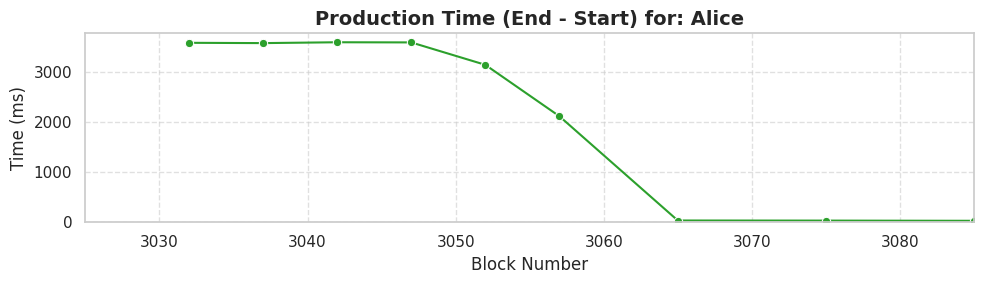

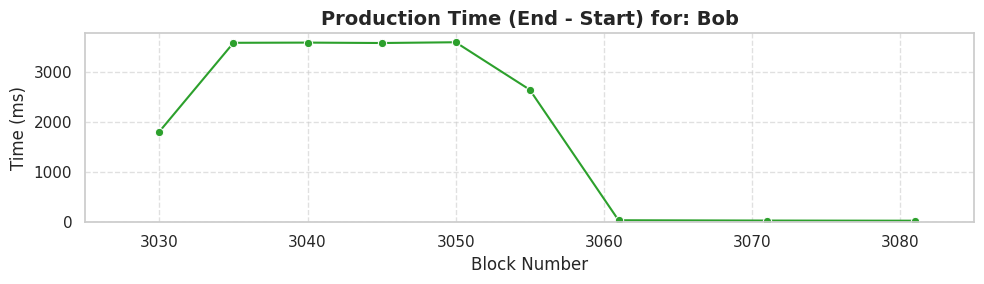

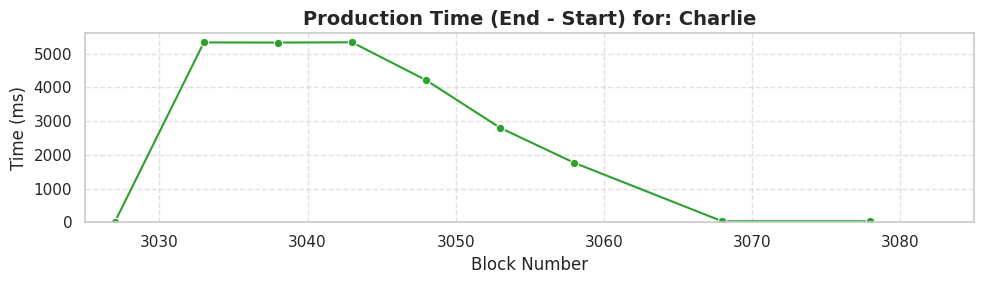

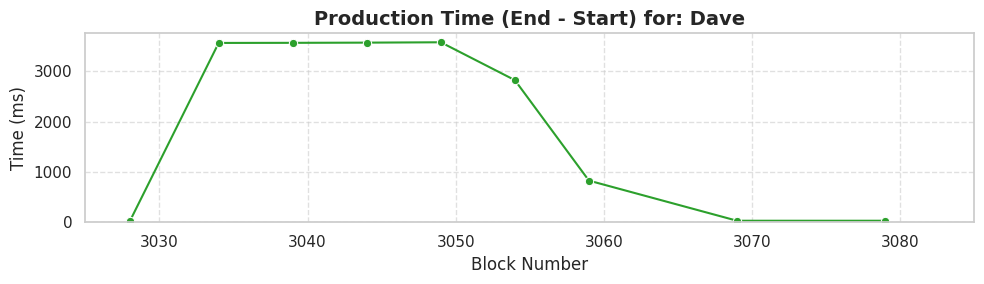

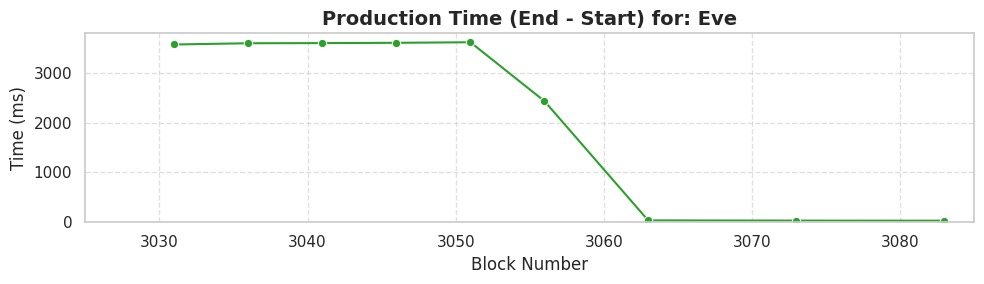

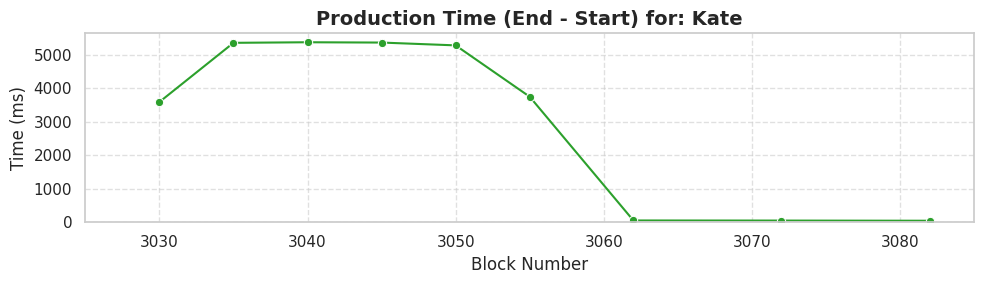

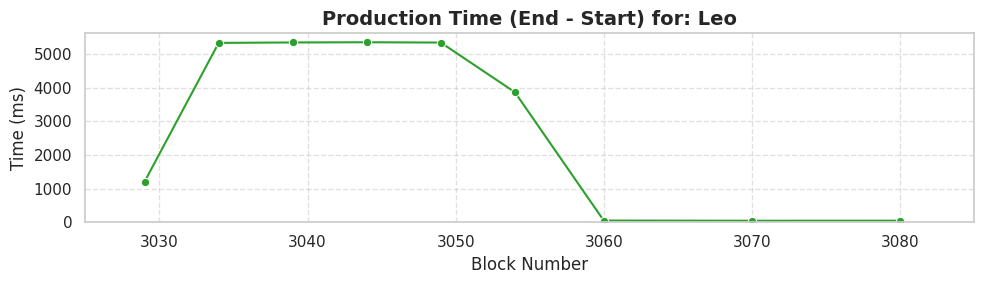

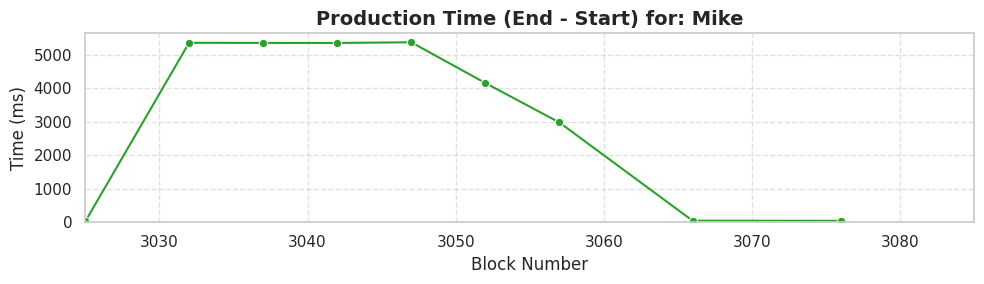

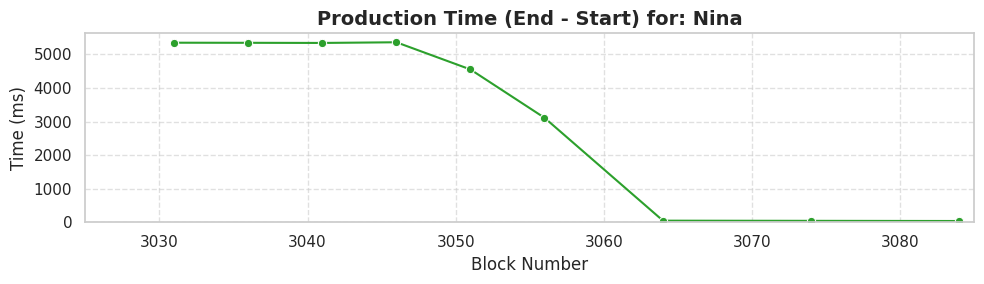

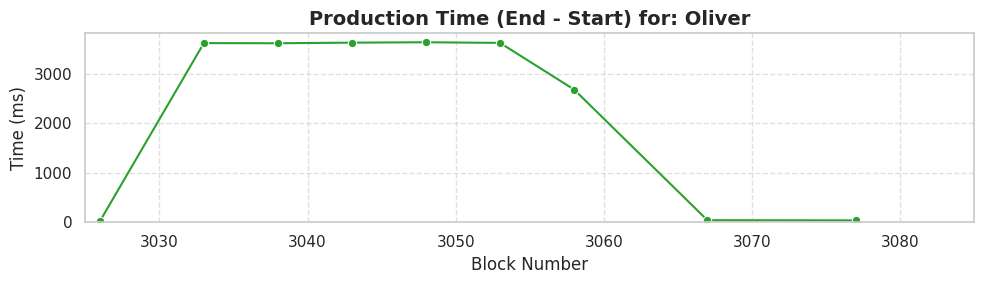

In [4]:
# 1. Get the list of nodes
unique_nodes = sorted(df['Node'].unique())

# 2. Determine global X-axis limits (so all charts match)
min_block = df['Block'].min()
max_block = df['Block'].max()

# Optional: Add a small buffer (e.g., -1/+1) so points aren't on the very edge
# min_block -= 1
# max_block += 1

# 3. Iterate and plot
for node in unique_nodes:
    # Filter data for this specific node
    node_data = df[df['Node'] == node]
    
    # Skip if no data for this node
    if node_data.empty:
        continue

    # Create a new figure for each node
    plt.figure(figsize=(10, 3))
    
    # Plot Production Time (End - Start)
    sns.lineplot(
        data=node_data, 
        x="Block", 
        y="ProductionTime_ms", 
        marker="o", 
        color="#2ca02c"  # Green color
    )
    
    # Formatting
    plt.title(f"Production Time (End - Start) for: {node}", fontsize=14, fontweight='bold')
    plt.ylabel("Time (ms)")
    plt.xlabel("Block Number")
    
    # --- CRITICAL CHANGE: Set the X-axis limits to the global range ---
    plt.xlim(min_block, max_block)
    
    # Ensure Y-axis starts at 0 for accurate scale
    plt.ylim(bottom=0)
    
    # Handle ticks: If the total range is small, show every integer. 
    # Otherwise, let Matplotlib decide to avoid overcrowding.
    if (max_block - min_block) < 50:
        # Create a range of all integers from min to max
        plt.xticks(range(int(min_block), int(max_block) + 1))
        
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()